In [14]:
!sudo apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [15]:
!pip install -U openai

In [3]:
from google.colab import userdata
import os
import openai

# Colab에 저장한 Secret에서 API 키 가져와 환경 변수에 등록
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

client = openai.OpenAI()

In [16]:
import pandas as pd

result_df = pd.read_csv('result_evaluation.csv')
result_df

,role,model,response,평가항목,점수,설명
0,당신은 친절한 초등학교 과학선생님입니다.,gpt-4o-mini,"양자이론은 자연과학 중 물리학의 한 분야로, 아주 작은 입자들, 예를 들어 원자나 ...",정확성,5,"응답 텍스트는 양자이론의 주요 개념인 양자화, 파동-입자 이중성, 불확정성 원리에 ..."
1,당신은 물리학과 대학교수입니다.,gpt-4o-mini,"양자이론(Quantum Theory)은 물리학의 한 분야로, 미시적 세계, 즉 원자...",일관성,5,모든 응답에서 양자이론의 주요 개념을 일관되게 유지하고 설명한다.
2,당신은 친절한 초등학교 과학선생님입니다.,gpt-3.5-turbo,양자이론은 미시세계에서 일어나는 현상을 설명하기 위해 고안된 물리 이론입니다. 양자...,톤 적절성,5,"응답이 이해하기 쉬운 톤으로 제공되어 있으며, 과학에 관심 있는 일반 대중을 대상으..."
3,NaN,NaN,NaN,포맷 적합성,4,"정보가 깔끔하게 제공되지만, 구성에 따라 텍스트 블록이 반복될 수 있는 여지가 있어..."


In [8]:
# 평균을 구할 컬럼 선택
columns = ['정확성', '일관성', '톤 적절성', '포맷 적합성']

# 평균 계산
mean_values = result_df[columns].mean()
mean_values

KeyError: "None of [Index(['정확성', '일관성', '톤 적절성', '포맷 적합성'], dtype='object')] are in the [columns]"

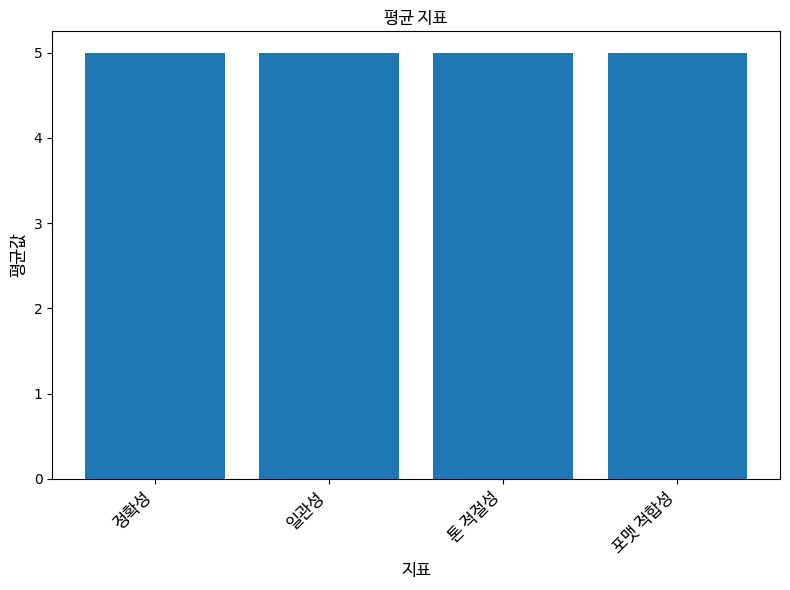

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd

# 한글 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'  # 나눔바른고딕 경로
fontprop = fm.FontProperties(fname=font_path, size=12)

# 바 그래프 그리기
plt.figure(figsize=(8, 6))  # 그래프 크기 설정
plt.bar(mean_values.index, mean_values.values)
plt.title('평균 지표', fontproperties=fontprop)  # 그래프 제목
plt.xlabel('지표', fontproperties=fontprop)  # x축 레이블
plt.ylabel('평균값', fontproperties=fontprop)  # y축 레이블
plt.xticks(rotation=45, ha='right', fontproperties=fontprop)  # x축 레이블 회전
plt.tight_layout()  # 레이블이 잘리지 않도록 설정
plt.show()  # 그래프 출력

In [ ]:
result_model_df = result_df.groupby('model')[columns].mean()
result_model_df

,정확성,일관성,톤 적절성,포맷 적합성
model,,,,
gpt-3.5-turbo,5.0,5.0,5.0,5.0
gpt-4o-mini,5.0,5.0,5.0,5.0


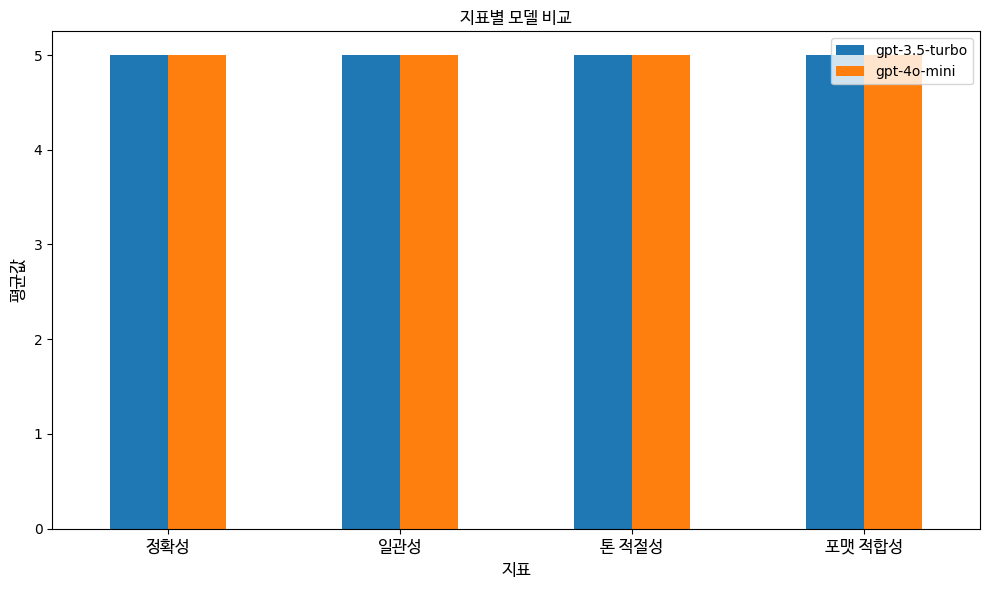

In [ ]:
# 데이터 변환
result_model_df_T = result_model_df.T  # 행과 열을 바꿉니다.

# 그래프 그리기
result_model_df_T.plot(kind='bar', figsize=(10, 6))
plt.title('지표별 모델 비교', fontproperties=fontprop)
plt.xlabel('지표', fontproperties=fontprop)
plt.ylabel('평균값', fontproperties=fontprop)
plt.xticks(rotation=0, ha='center', fontproperties=fontprop)  # x축 레이블 회전하지 않음
plt.legend()
plt.tight_layout()
plt.show()